# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Loading data

In [2]:
df_features = pd.read_csv("../dataset/40_features.csv")
df_distances = pd.read_csv("../dataset/distances.csv")
df_distances = df_distances[:df_features.shape[0]]
X = df_features.values
y = df_distances.iloc[:, 0].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/40_features.csv'

# Matriz de correlação entre features e o target

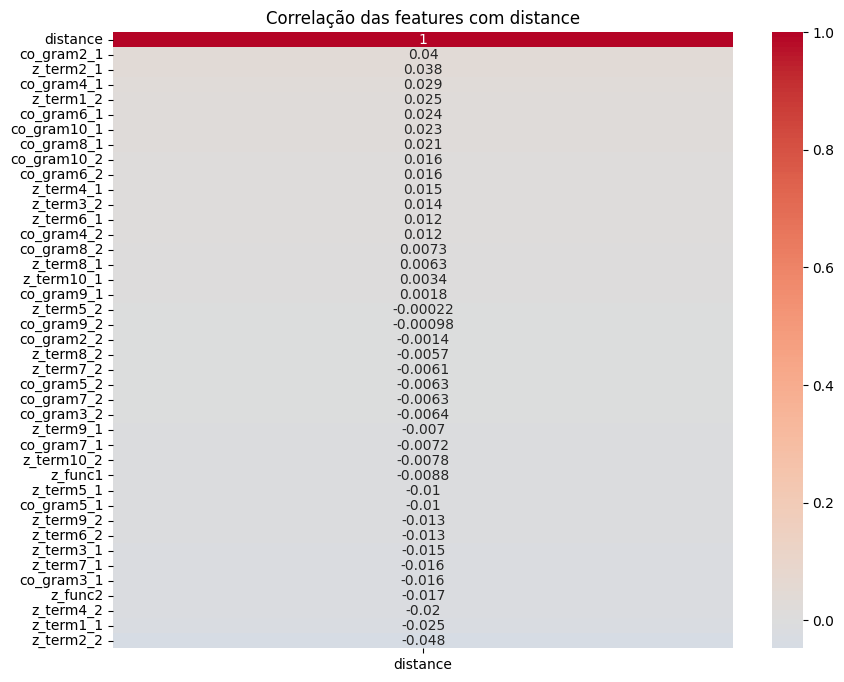

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


df = pd.concat([df_features, df_distances], axis=1)

correlation = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation[["distance"]].sort_values(by="distance", ascending=False), annot=True, cmap="coolwarm", center=0)
plt.title("Correlação das features com distance")
plt.show()

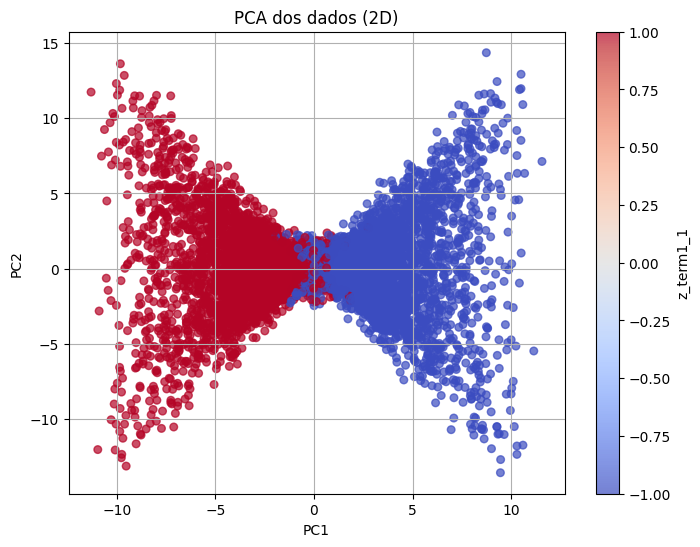

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=30, alpha=0.7)
plt.colorbar(sc, label="z_term1_1")
plt.title("PCA dos dados (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# SVR

In [ ]:
C_values = [0.1, 1.0, 10.0]
epsilon_values = [0.01, 0.1, 0.2]
results = []

for C in C_values:
    for epsilon in epsilon_values:
        svr = SVR(kernel='rbf', epsilon=epsilon, C=C)
        start_time = time.time()
        svr.fit(X_train, y_train)
        y_pred = svr.predict(X_test)
        end_time = time.time()
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results.append({
            "C": C,
            "epsilon": epsilon,
            "mse": mse,
            "r2": r2,
            "execution_time": end_time - start_time,
        })

df_results = pd.DataFrame(results)
print(df_results)


      C  epsilon       mse        r2  execution_time
0   0.1     0.01  0.019261  0.809689        2.558026
1   0.1     0.10  0.023108  0.771679        0.904474
2   0.1     0.20  0.028662  0.716805        0.385188
3   1.0     0.01  0.010662  0.894654        5.613644
4   1.0     0.10  0.015013  0.851667        0.705704
5   1.0     0.20  0.022546  0.777237        0.275522
6  10.0     0.01  0.009906  0.902126       18.178920
7  10.0     0.10  0.014368  0.858038        1.093996
8  10.0     0.20  0.022543  0.777259        0.412653
